<a href="https://colab.research.google.com/github/red-gunslinger/Int-Comp/blob/main/5_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [48]:
import random

import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

True

In [50]:
import os

try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if os.path.exists("/content/train.csv"):
    data_base_path = "/content/"
elif os.path.exists("./train.csv"):
    data_base_path = "./"
elif os.path.exists("./data/train.csv"):
    data_base_path = "./data/"
else:
    data_base_path = "../data/asl_data/"

print(data_base_path)

/content/


### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [51]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [52]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

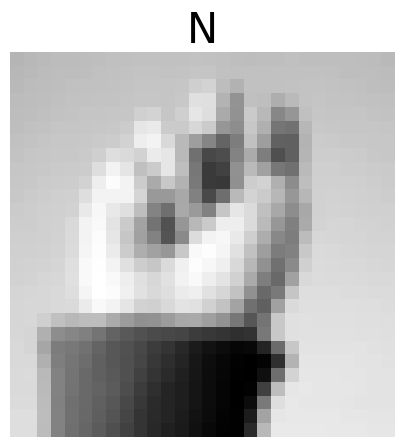

In [53]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [54]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [55]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [56]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well.

In [57]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [58]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(_num_epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [59]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [60]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [61]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:41<00:00,  2.08s/epoch, train_acc=0.9039, train_loss=0.2760, val_acc=0.7987, val_loss=0.8456]


In [62]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [63]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [64]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [00:55<00:00,  2.77s/epoch, train_acc=0.9978, train_loss=0.0078, val_acc=0.9649, val_loss=0.1736]


In [65]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

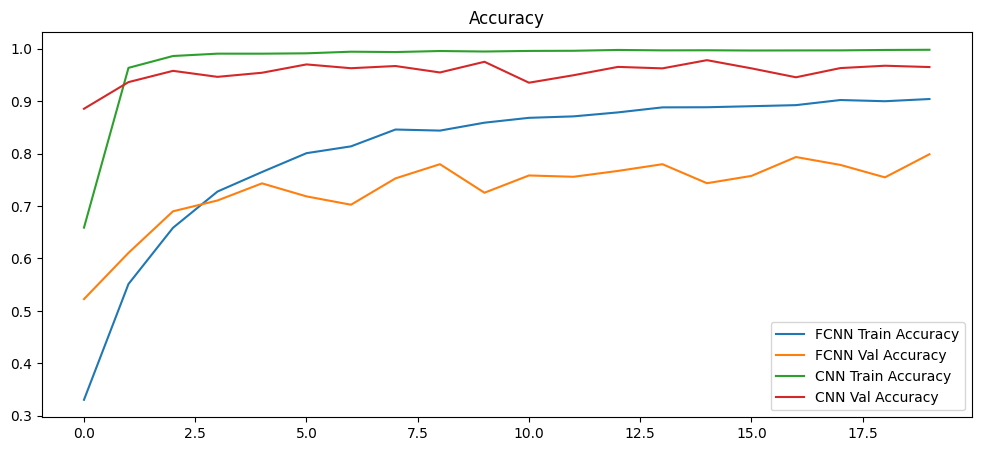

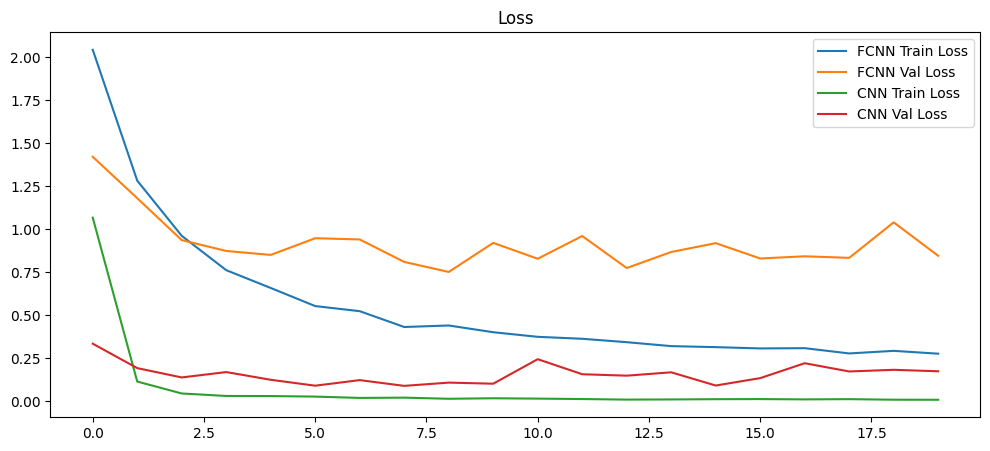

In [66]:
plt.figure(figsize=(12, 5))
plt.plot(fcnn_res['train_acc'], label='FCNN Train Accuracy')
plt.plot(fcnn_res['val_acc'], label='FCNN Val Accuracy')
plt.plot(cnn_res['train_acc'], label='CNN Train Accuracy')
plt.plot(cnn_res['val_acc'], label='CNN Val Accuracy')
plt.legend()
plt.title('Accuracy')
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(fcnn_res['train_loss'], label='FCNN Train Loss')
plt.plot(fcnn_res['val_loss'], label='FCNN Val Loss')
plt.plot(cnn_res['train_loss'], label='CNN Train Loss')
plt.plot(cnn_res['val_loss'], label='CNN Val Loss')
plt.legend()
plt.title('Loss')
plt.show()

In [67]:
fcnn_params = sum(p.numel() for p in model_fcnn.parameters() if p.requires_grad)
cnn_params = sum(p.numel() for p in model_cnn.parameters() if p.requires_grad)

print("FCNN parameters:", fcnn_params)
print("CNN parameters:", cnn_params)

FCNN parameters: 676888
CNN parameters: 403799


## Reflection section

### Which model is better at classifying ASL images?

CNN is better at classifying ASL images because it can show edges and shapes very well. This allows it to understand image structure more effectively than a FCNN.


### Which model was _faster_ to train?

FCNN was faster to train because it has a simpler structure and does not perform convolution and pooling operations.

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

Both models improved over epochs, but the CNN reached higher validation accuracy and had much more stable performance. The FCNN improved during training, but its validation accuracy stayed lower. This shows that the CNN might have generalized better on unseen data.



### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

The FCNN has 676888 trainable parameters

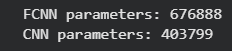

### How do the models compare in terms of overfitting? Why do you think that is the case?

The FC model is more prone to overfitting because the gap between training and validation performance is larger. Its training accuracy increases well, but validation accuracy stays visibly lower. The CNN also shows some gap between training and validation performance, but it generalizes much, much better.

This is probably because convolutional layers store spatial information and use shared weights, which makes the model more effective for image data.


### Final conclusions and remarks

The CNN is the best model for this task. It achieved much higher validation accuracy and lower validation loss than the Fully Connected Neural Network. Even with fewer trainable parameters, it performed better because it is designed to learn spatial patterns in images. This assignment went well for me in general, only had a few hiccups because some of my keys stick to the keyboard for a few seconds. I had to rewrite some code multiple times cause of this.